In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load dataset
# Dataset: SMS Spam Collection from UCI
url = 'https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv'
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


label
ham     4825
spam     747
Name: count, dtype: int64


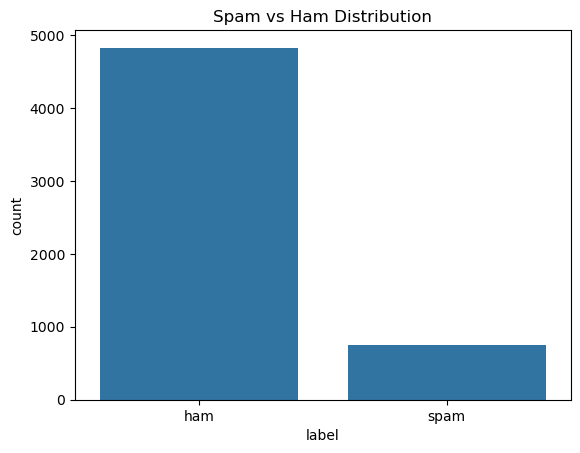

In [5]:
# Check class distribution
print(df['label'].value_counts())
sns.countplot(x='label', data=df)
plt.title('Spam vs Ham Distribution')
plt.show()

In [6]:
# Encode labels: spam=1, ham=0
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})
df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [9]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # lowercase
    text = text.lower()
    # remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    # tokenize
    words = text.split()
    # remove stopwords and stem
    words = [stemmer.stem(w) for w in words if w not in stop_words and len(w) > 2]
    return ' '.join(words)

df['clean_message'] = df['message'].apply(clean_text)
df[['message', 'clean_message']].head()

[nltk_data] Downloading package stopwords to C:\Users\Fatima
[nltk_data]     Athar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Fatima
[nltk_data]     Athar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",jurong point crazi avail bugi great world buff...
1,Ok lar... Joking wif u oni...,lar joke wif oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win cup final tkt may tex...
3,U dun say so early hor... U c already then say...,dun say earli hor alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


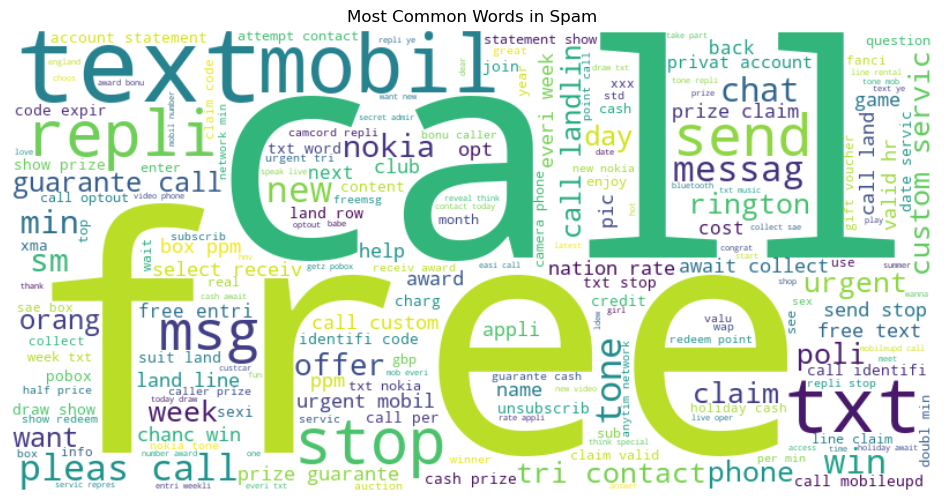

In [10]:
# Visualize most common words in spam
from wordcloud import WordCloud

spam_words = ' '.join(df[df['label_num'] == 1]['clean_message'])
wc = WordCloud(width=800, height=400, background_color='white').generate(spam_words)
plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Spam')
plt.show()

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_message'])
y = df['label_num']

print('Feature matrix shape:', X.shape)

Feature matrix shape: (5572, 5000)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Train size:', X_train.shape)
print('Test size:', X_test.shape)

Train size: (4457, 5000)
Test size: (1115, 5000)


In [13]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print('Accuracy:', round(accuracy_score(y_test, y_pred) * 100, 2), '%')
print()
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

Accuracy: 96.86 %

              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       0.99      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



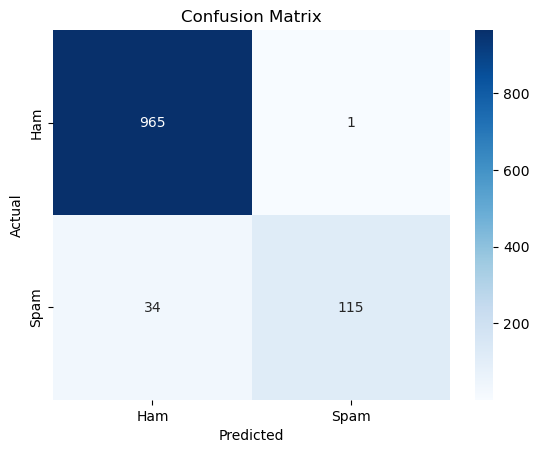

In [14]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [15]:
import pickle

pickle.dump(model, open('spam_model.pkl', 'wb'))
pickle.dump(tfidf, open('spam_vectorizer.pkl', 'wb'))

print('Model and vectorizer saved successfully!')

Model and vectorizer saved successfully!


In [16]:
# Quick test
test_emails = [
    'Congratulations! You have won a free iPhone. Click here to claim now!',
    'Hey, are we still meeting for lunch tomorrow?',
    'URGENT: Your account has been compromised. Send your password immediately.',
    'Please find the attached report for the quarterly review.'
]

for email in test_emails:
    cleaned = clean_text(email)
    vec = tfidf.transform([cleaned])
    pred = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0]
    label = 'SPAM' if pred == 1 else 'HAM'
    conf = round(prob[pred] * 100, 2)
    print(f'[{label}] ({conf}%) — {email[:60]}...')

[SPAM] (71.39%) — Congratulations! You have won a free iPhone. Click here to c...
[HAM] (99.82%) — Hey, are we still meeting for lunch tomorrow?...
[SPAM] (55.37%) — URGENT: Your account has been compromised. Send your passwor...
[HAM] (82.56%) — Please find the attached report for the quarterly review....
